# Attention Pattern Visualization with TransformerLens

Clean notebook for exploring attention patterns in GPT-2 style models.

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformer_lens import HookedTransformer

%matplotlib inline

In [14]:
# Load model through TransformerLens
model = HookedTransformer.from_pretrained("gpt2-xl")
print(f"Model loaded: {model.cfg.n_layers} layers, {model.cfg.n_heads} heads per layer")

Loaded pretrained model gpt2-xl into HookedTransformer
Model loaded: 48 layers, 25 heads per layer


In [15]:
def plot_attention_pattern(attention, tokens, layer, head, ax=None):
    """
    Plot a single attention head's pattern as a heatmap.
    
    Args:
        attention: [seq, seq] attention pattern
        tokens: list of token strings
        layer: layer index (for title)
        head: head index (for title)
        ax: matplotlib axis (creates new figure if None)
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 10))
    
    sns.heatmap(
        attention.cpu().numpy(),
        xticklabels=tokens,
        yticklabels=tokens,
        cmap="Blues",
        ax=ax,
        vmin=0,
        vmax=1
    )
    ax.set_xlabel("Source (keys)")
    ax.set_ylabel("Destination (queries)")
    ax.set_title(f"Layer {layer}, Head {head}")
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    
    return ax

In [16]:
# Run a prompt and cache activations
prompt = "A screen reader is"
tokens = model.to_tokens(prompt)
str_tokens = model.to_str_tokens(prompt)

print(f"Tokens: {str_tokens}")

# Run with cache to get attention patterns
_, cache = model.run_with_cache(tokens)

Tokens: ['<|endoftext|>', 'A', ' screen', ' reader', ' is']


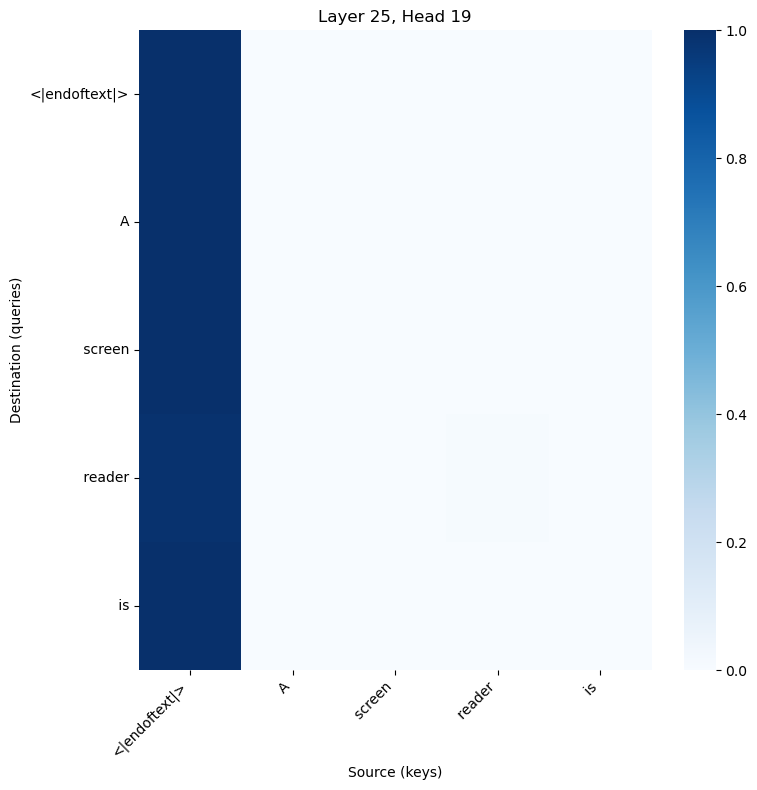

In [20]:
# Visualize a single attention head
layer = 25
head = 19

# Get attention pattern: cache["pattern", layer] has shape [batch, head, seq, seq]
attention = cache["pattern", layer][0, head]  # [seq, seq]

fig, ax = plt.subplots(figsize=(8, 8))
plot_attention_pattern(attention, str_tokens, layer, head, ax)
plt.tight_layout()
plt.show()

Plotting 25 heads for layer 25


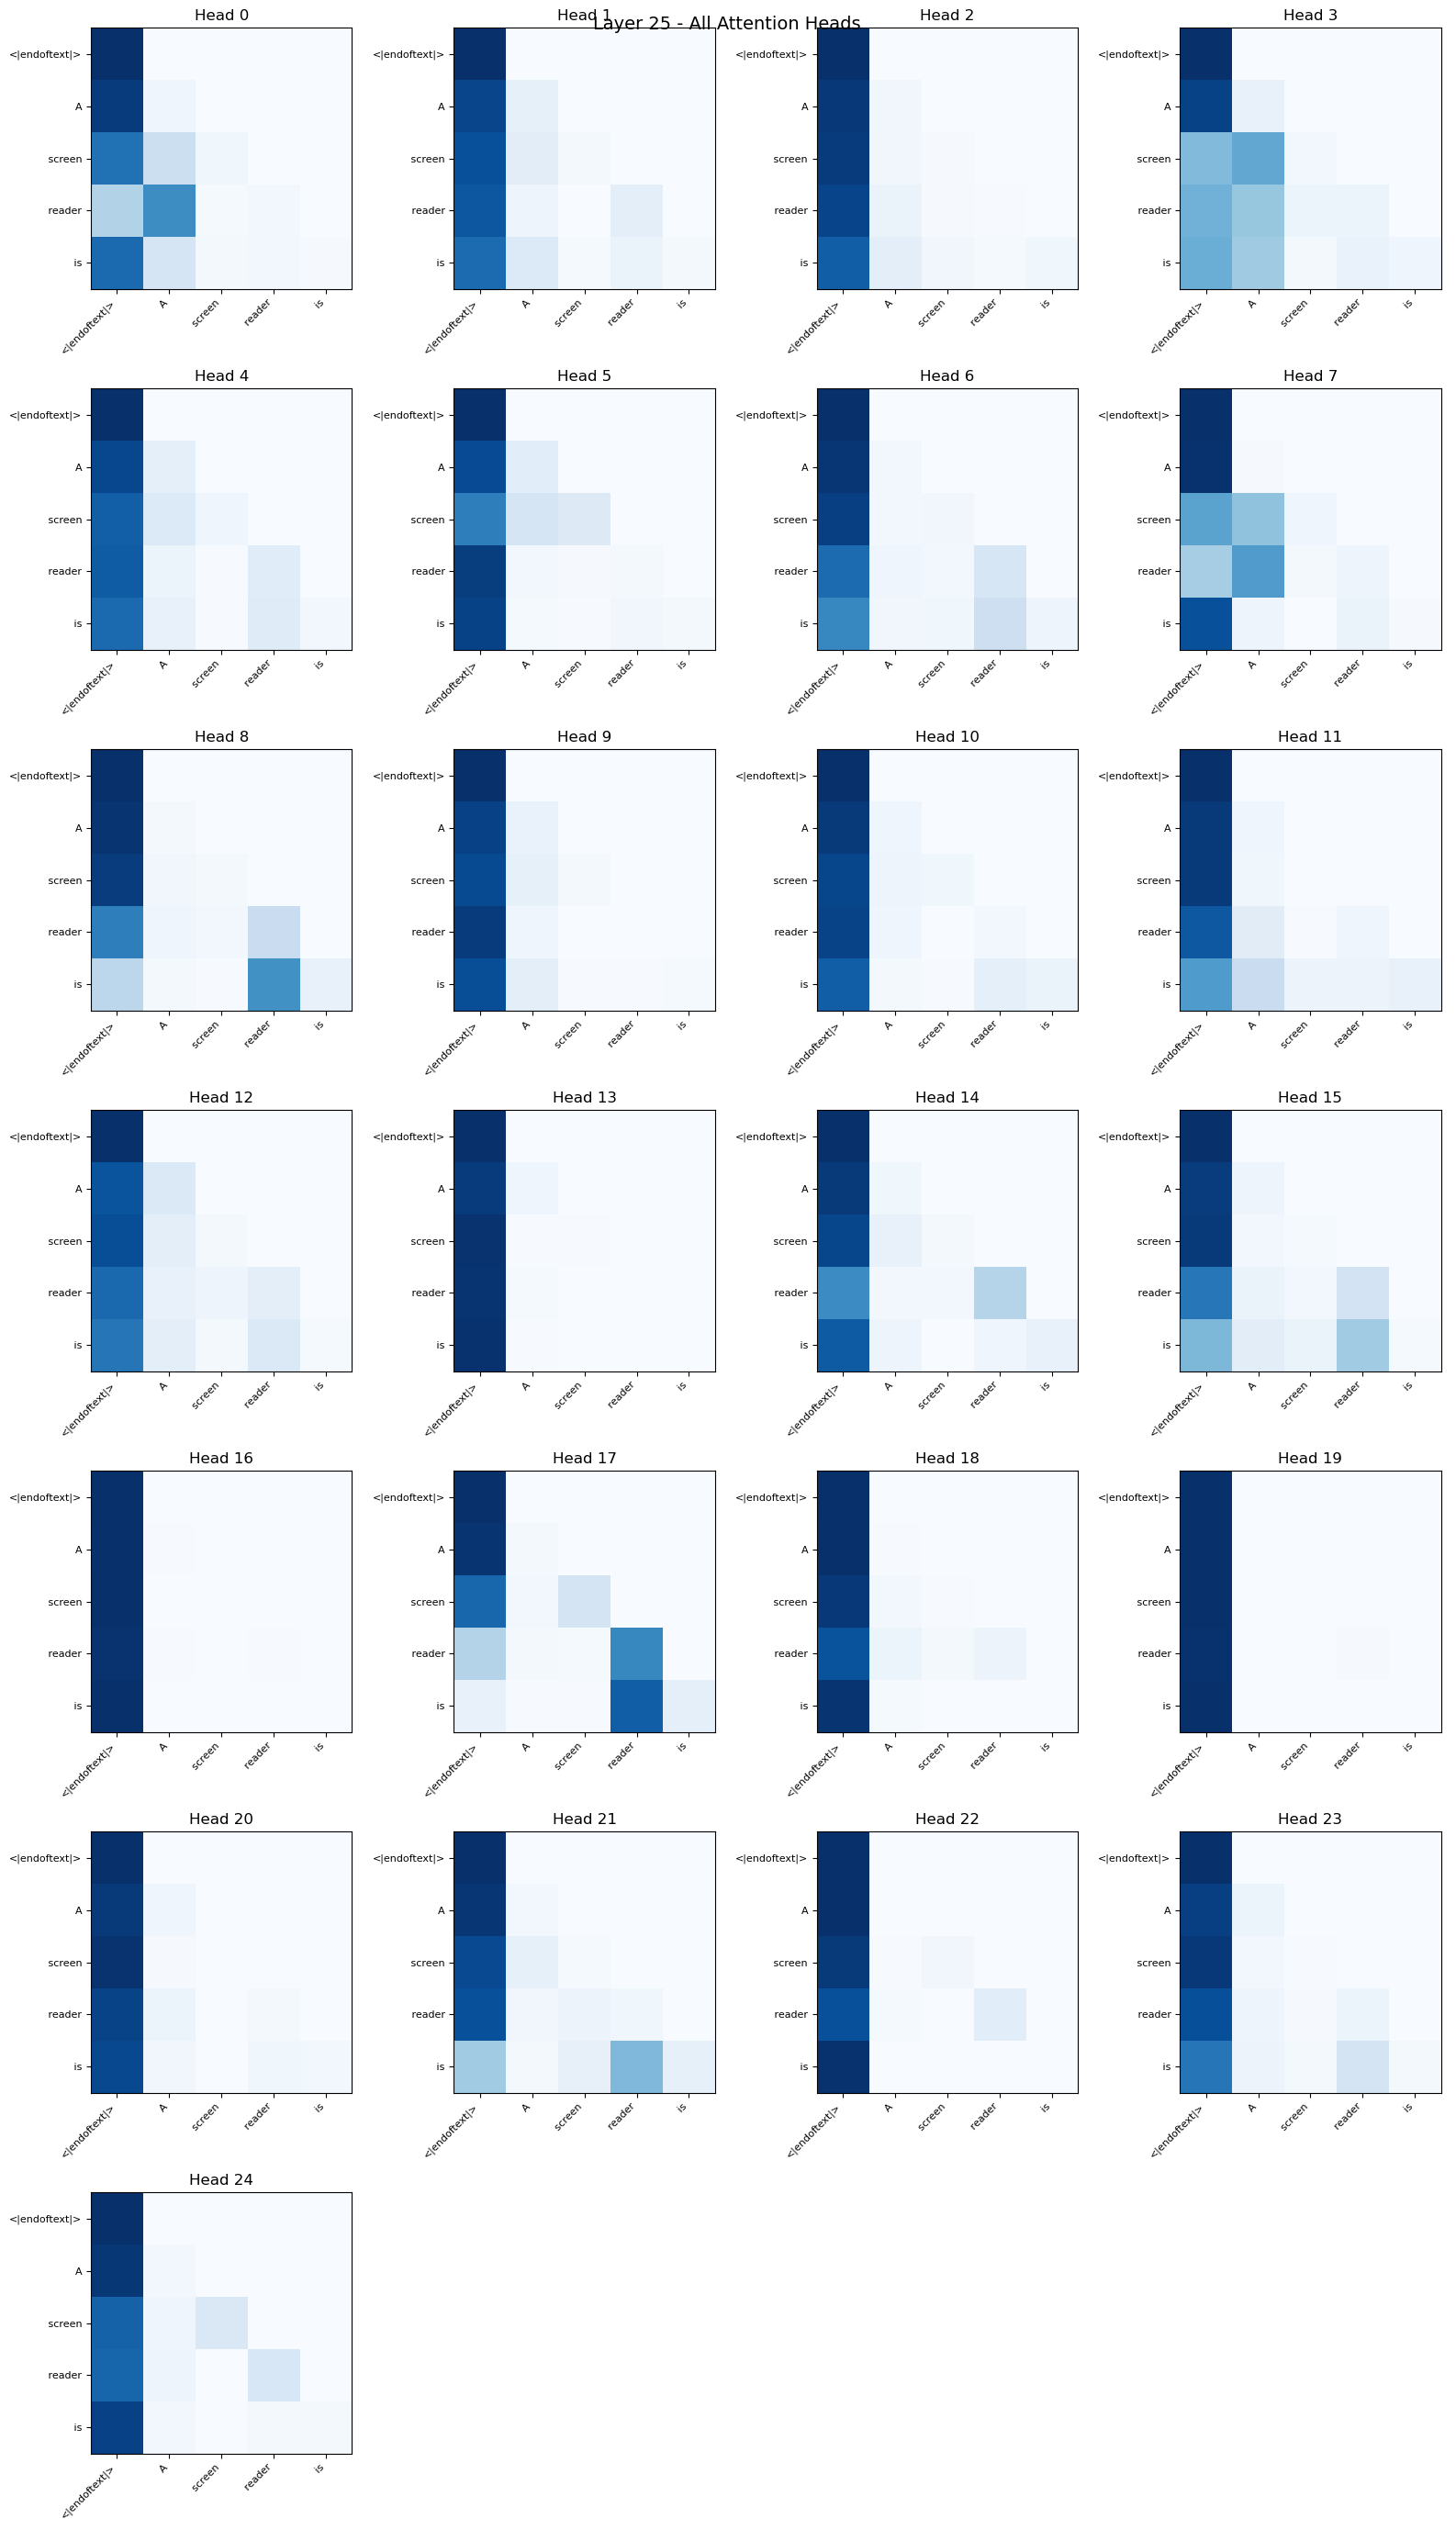

In [21]:
# Visualize all heads in a single layer
layer = 25
n_heads = model.cfg.n_heads

print(f"Plotting {n_heads} heads for layer {layer}")

# Dynamically size the grid
n_cols = 4
n_rows = (n_heads + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
axes_flat = np.array(axes).flatten()

for head_idx in range(n_heads):
    attention = cache["pattern", layer][0, head_idx]
    ax = axes_flat[head_idx]
    
    im = ax.imshow(attention.cpu().numpy(), cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"Head {head_idx}")
    ax.set_xticks(range(len(str_tokens)))
    ax.set_yticks(range(len(str_tokens)))
    ax.set_xticklabels(str_tokens, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(str_tokens, fontsize=8)

# Hide unused axes
for idx in range(n_heads, len(axes_flat)):
    axes_flat[idx].axis('off')

plt.suptitle(f"Layer {layer} - All Attention Heads", fontsize=14)
plt.tight_layout()
plt.show()

In [19]:
# Which heads attend most to a specific token position?
target_position = -1  # Last token (where we predict from)
source_position = 0   # BOS token

attention_scores = []

for layer_idx in range(model.cfg.n_layers):
    for head_idx in range(model.cfg.n_heads):
        attn = cache["pattern", layer_idx][0, head_idx, target_position, source_position].item()
        attention_scores.append((layer_idx, head_idx, attn))

# Sort by attention score (descending)
attention_scores.sort(key=lambda x: x[2], reverse=True)

print(f"Top 10 heads attending from position {target_position} to position {source_position}:")
print(f"(Token '{str_tokens[target_position]}' attending to '{str_tokens[source_position]}')\n")

for layer_idx, head_idx, score in attention_scores[:10]:
    print(f"  L{layer_idx}H{head_idx}: {score:.4f}")

Top 10 heads attending from position -1 to position 0:
(Token ' is' attending to '<|endoftext|>')

  L25H19: 0.9985
  L41H20: 0.9983
  L37H23: 0.9978
  L19H18: 0.9976
  L41H4: 0.9976
  L26H13: 0.9976
  L35H5: 0.9969
  L38H23: 0.9967
  L7H4: 0.9966
  L44H24: 0.9966


In [22]:
# Clean up GPU memory if needed
del cache
torch.cuda.empty_cache() if torch.cuda.is_available() else None